# 🎯 K-Means Clustering — Beginner's Guide
### Real Use Case: Customer Segmentation for a Shopping Mall

---

## 🤔 What is Clustering?

Imagine you walk into a **library**. Books are NOT randomly placed everywhere.

They are **grouped** (clustered) into:
- 📚 Science Fiction
- 🔍 Mystery
- 💕 Romance
- 📖 History

Nobody told the librarian "this book is Science Fiction" — the librarian **figured it out from the content** and grouped similar books together.

**That's exactly what Clustering does with data!**

---

## 🏪 Real Use Case: Mall Customer Segmentation

A mall manager wants to understand their customers:
- Who are the **high spenders**?
- Who comes often but **spends less**?
- Who has **high income but doesn't spend much**?

By clustering customers, the mall can **send the right offer to the right customer!**

| Customer Group | Strategy |
|---|---|
| High income, High spend | VIP membership offers |
| Low income, High spend | Discount deals |
| High income, Low spend | Targeted premium ads |
| Low income, Low spend | Budget-friendly promotions |

---

## 📚 What We'll Learn Today

1. **Clustering Intuition** — What it is, how it works
2. **K-Means Algorithm** — Step by step
3. **Elbow Method** — How to find the right number of clusters
4. **Visualize Clusters** — See the groups clearly
5. **Business Insights** — What do these clusters mean?

---
## 📦 Step 1: Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Make plots look nice
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ All libraries imported!")

✅ All libraries imported!


---
## 🛒 Step 2: Load the Mall Customer Dataset

This is a famous beginner dataset. Each row = one customer.

| Column | Meaning |
|---|---|
| `CustomerID` | Unique ID |
| `Gender` | Male / Female |
| `Age` | Age of customer |
| `Annual Income (k$)` | Yearly income in thousands |
| `Spending Score (1-100)` | Mall-assigned score based on spending behavior |

In [19]:
# We'll create the dataset directly (same as the famous Mall_Customers.csv)
# In real projects: df = pd.read_csv('Mall_Customers.csv')

np.random.seed(42)

n = 200

# Simulate 5 natural customer groups
groups = [
    # (income_mean, income_std, spending_mean, spending_std, count)
    (25,  7,  78, 8,  40),   # Group A: Low income, High spenders (impulsive buyers)
    (55,  8,  55, 7,  40),   # Group B: Mid income, Mid spenders (average customers)
    (88,  8,  82, 7,  40),   # Group C: High income, High spenders (VIP customers)
    (88,  7,  18, 8,  40),   # Group D: High income, Low spenders (careful rich)
    (28,  7,  20, 7,  40),   # Group E: Low income, Low spenders (budget shoppers)
]

incomes, scores, genders, ages = [], [], [], []
for inc_m, inc_s, sp_m, sp_s, count in groups:
    incomes.extend(np.random.normal(inc_m, inc_s, count).clip(10, 120).astype(int))
    scores.extend(np.random.normal(sp_m, sp_s, count).clip(1, 100).astype(int))
    genders.extend(np.random.choice(['Male', 'Female'], count))
    ages.extend(np.random.randint(18, 70, count))

df = pd.DataFrame({
    'CustomerID': range(1, n + 1),
    'Gender': genders,
    'Age': ages,
    'Annual_Income_k': incomes,
    'Spending_Score': scores
})

print(f"✅ Dataset created with {len(df)} customers")
print(f"\n📋 Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset created with 200 customers

📋 Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Female,44,28,83
1,2,Male,69,24,79
2,3,Male,30,29,77
3,4,Male,58,35,75
4,5,Male,20,23,66


In [20]:
# Basic info
print("📊 Dataset Summary")
print("=" * 35)
print(df.describe().round(2))
print()
print(f"Gender distribution:")
print(df['Gender'].value_counts().to_string())
print(f"\nAny missing values? {df.isnull().sum().sum()}")

📊 Dataset Summary
       CustomerID     Age  Annual_Income_k  Spending_Score
count      200.00  200.00           200.00          200.00
mean       100.50   43.42            55.40           50.46
std         57.88   15.77            28.83           28.52
min          1.00   18.00            11.00            4.00
25%         50.75   29.00            27.75           21.00
50%        100.50   44.50            55.50           56.00
75%        150.25   56.25            84.00           78.00
max        200.00   69.00           105.00           96.00

Gender distribution:
Gender
Male      101
Female     99

Any missing values? 0


---
## 👀 Step 3: Explore the Data Visually

Before clustering, let's look at the raw data — can you already spot any natural groups?

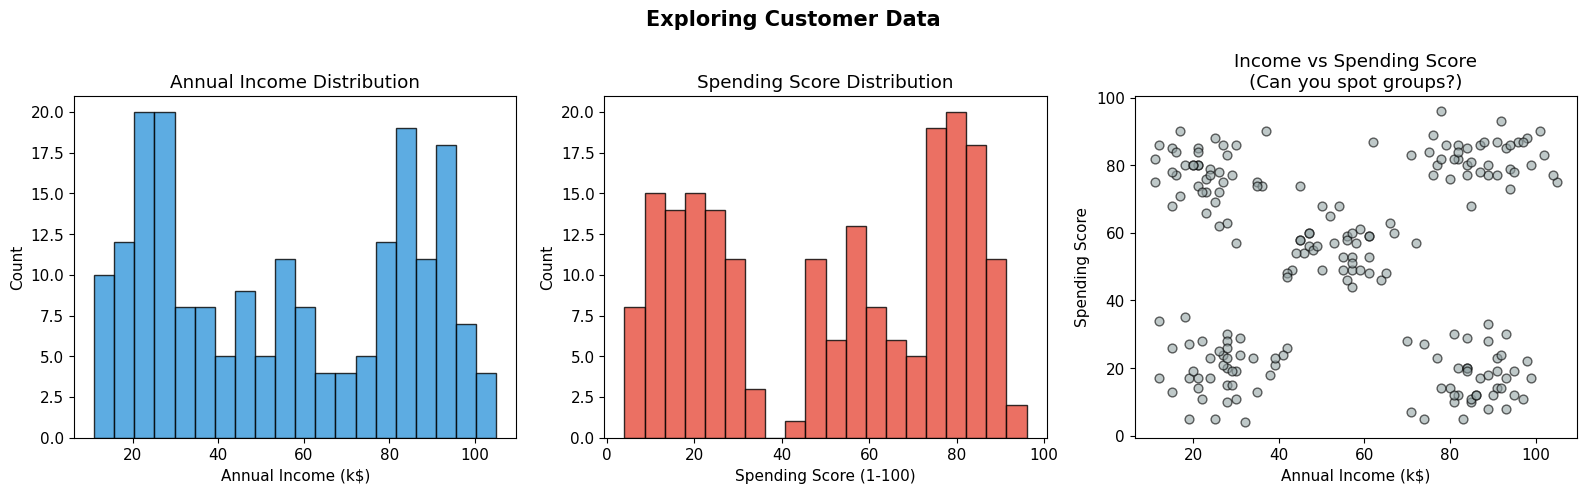

🔍 Look at the 3rd plot — you can already see some natural groupings!
   K-Means will find and label them automatically for us.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploring Customer Data', fontsize=15, fontweight='bold')

# Plot 1: Income distribution
axes[0].hist(df['Annual_Income_k'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Annual Income Distribution')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Count')

# Plot 2: Spending Score distribution
axes[1].hist(df['Spending_Score'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Spending Score Distribution')
axes[1].set_xlabel('Spending Score (1-100)')
axes[1].set_ylabel('Count')

# Plot 3: Raw scatter - Income vs Spending
axes[2].scatter(df['Annual_Income_k'], df['Spending_Score'],
                color='#95a5a6', edgecolor='black', alpha=0.6, s=40)
axes[2].set_title('Income vs Spending Score\n(Can you spot groups?)')
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Spending Score')

plt.tight_layout()
plt.show()

print("🔍 Look at the 3rd plot — you can already see some natural groupings!")
print("   K-Means will find and label them automatically for us.")

---
## 🧠 Step 4: How K-Means Works (The Intuition)

K-Means follows a simple 4-step loop:

```
STEP 1: Pick K random points as "Centroids" (cluster centers)

    ★ = Centroid

    .  .  .  ★  .  .          ← K=3, so 3 random centroids placed
    .  .  .  .  .  .
    ★  .  .  .  .  ★

STEP 2: Assign each point to the NEAREST centroid

    R  R  R  ★  B  B          ← R = close to left centroid
    R  R  G  G  B  B          ← B = close to right centroid
    ★  R  G  G  B  ★          ← G = close to bottom centroid

STEP 3: Move each centroid to the CENTER of its assigned points

    R  R  R     B  B          ← Centroid moved to middle of R cluster
    R  R ★G  G  B  B          ← G centroid moved up
       R  G ★G  B★

STEP 4: Repeat Steps 2 and 3 until centroids stop moving
```

**That's it!** When centroids stop moving → clustering is done ✅

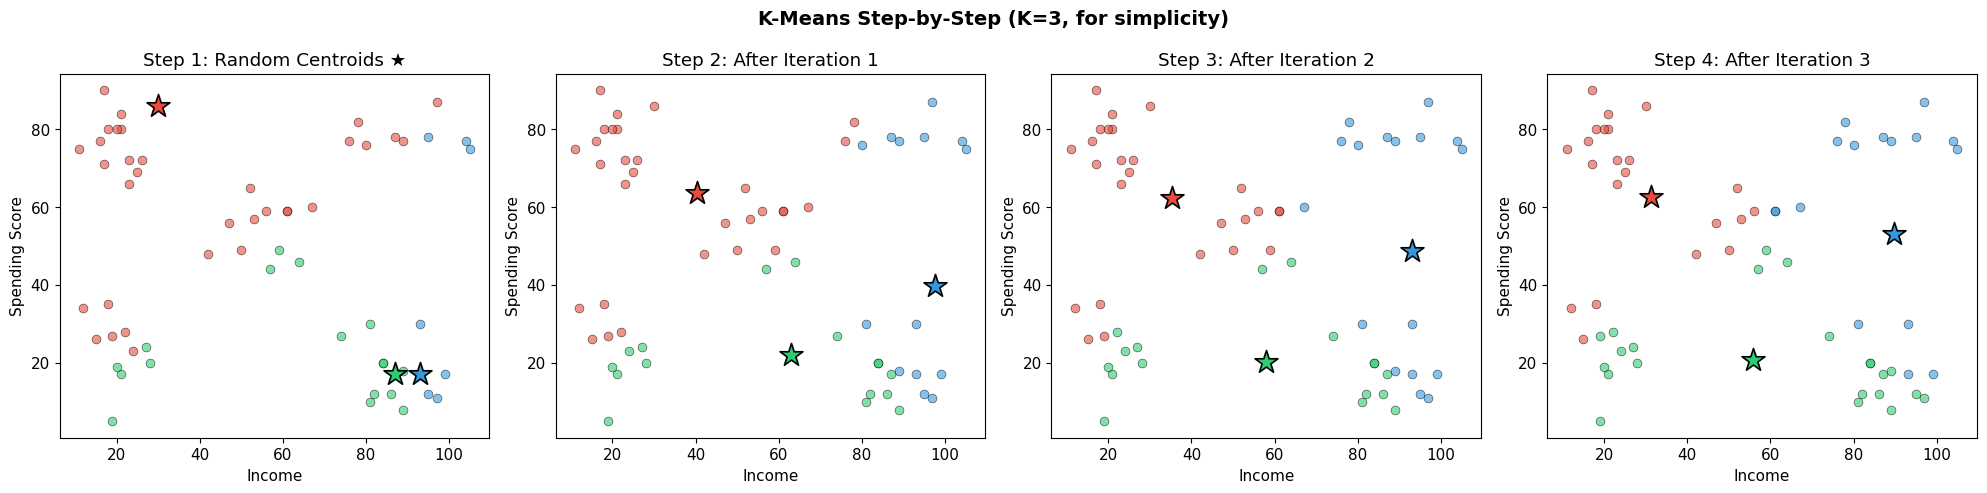

Notice how the ★ centroids MOVE each iteration until clusters stabilize!


In [22]:
# Let's VISUALIZE K-Means step by step with a simple 2D example
# We'll animate 3 iterations so you can SEE how centroids move

# Use a tiny subset for clarity
np.random.seed(0)
sample = df[['Annual_Income_k', 'Spending_Score']].sample(60).values

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('K-Means Step-by-Step (K=3, for simplicity)', fontsize=14, fontweight='bold')

COLORS = ['#e74c3c', '#3498db', '#2ecc71']
STAR = '*'
K = 3

# Initial random centroids
centroid_idx = np.random.choice(len(sample), K, replace=False)
centroids = sample[centroid_idx].copy().astype(float)

for step in range(4):
    ax = axes[step]

    # Assign clusters
    dists = np.array([[np.linalg.norm(p - c) for c in centroids] for p in sample])
    labels = np.argmin(dists, axis=1)

    # Plot points
    for k in range(K):
        pts = sample[labels == k]
        ax.scatter(pts[:, 0], pts[:, 1],
                   color=COLORS[k], alpha=0.6, s=40, edgecolors='black', linewidths=0.5)
        ax.scatter(centroids[k, 0], centroids[k, 1],
                   color=COLORS[k], marker='*', s=300, edgecolors='black', linewidths=1.2,
                   zorder=5)

    if step == 0:
        ax.set_title(f'Step 1: Random Centroids ★')
    else:
        ax.set_title(f'Step {step+1}: After Iteration {step}')

    ax.set_xlabel('Income')
    ax.set_ylabel('Spending Score')

    # Update centroids (move to center of cluster)
    for k in range(K):
        if (labels == k).sum() > 0:
            centroids[k] = sample[labels == k].mean(axis=0)

plt.tight_layout()
plt.show()
print("Notice how the ★ centroids MOVE each iteration until clusters stabilize!")

---
## ❓ Step 5: How Many Clusters? — The Elbow Method

K-Means needs us to tell it **how many clusters (K)** to make.

**But how do we know the right K?**

We use the **Elbow Method**!

**WCSS** = Within-Cluster Sum of Squares = total distance of all points from their centroid.
- Lower WCSS = tighter, better clusters
- As K increases, WCSS always decreases
- **Find the "elbow" — where the decrease suddenly slows down**

```
WCSS
 │
 │  ●
 │     ●
 │        ●  ← Elbow here! (K=5)
 │           ●  ●  ●  ●
 └──────────────────────── K
    1  2  3  4  5  6  7
```

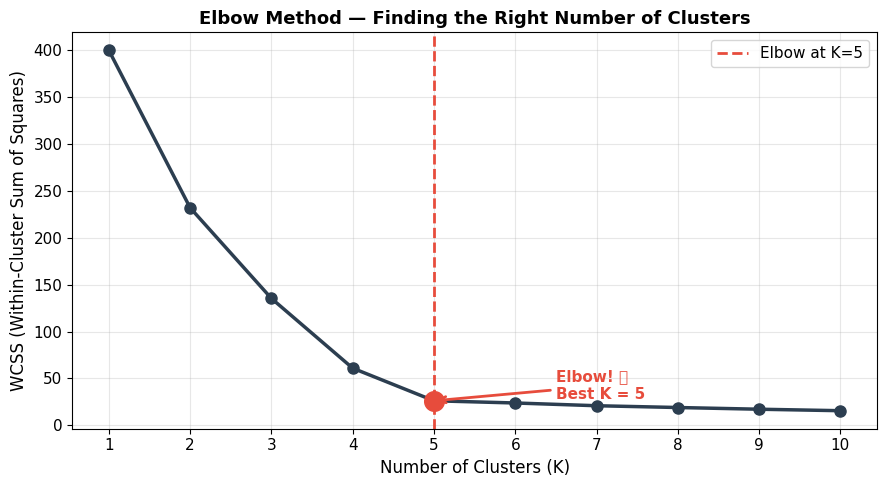

📌 The curve 'bends' at K=5 — adding more clusters after that gives very little improvement.
   So we'll use K = 5 for our mall customer segmentation!


In [23]:
# We'll cluster on Income + Spending Score (2 features — easy to visualize)
X = df[['Annual_Income_k', 'Spending_Score']].values

# Scale the features
# (Important! If income is 80 and spending is 60, they should be on same scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try K from 1 to 10 and record WCSS
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)   # inertia_ = WCSS

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, 'o-', color='#2c3e50', linewidth=2.5, markersize=8)
plt.axvline(x=5, color='#e74c3c', linestyle='--', linewidth=2, label='Elbow at K=5')
plt.scatter([5], [wcss[4]], color='#e74c3c', s=200, zorder=5)
plt.annotate('Elbow! 👈\nBest K = 5',
             xy=(5, wcss[4]), xytext=(6.5, wcss[4] + 2),
             fontsize=11, color='#e74c3c', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))
plt.title('Elbow Method — Finding the Right Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("📌 The curve 'bends' at K=5 — adding more clusters after that gives very little improvement.")
print("   So we'll use K = 5 for our mall customer segmentation!")

---
## ✅ Step 6: Silhouette Score — Another Way to Validate K

**Silhouette Score** measures how well each point fits its own cluster vs other clusters.

- Range: **-1 to +1**
- Close to **+1** = well-clustered ✅
- Close to **0** = on border between clusters ⚠️
- Negative = probably in the wrong cluster ❌

In [24]:
sil_scores = []

for k in range(2, 11):   # silhouette needs at least 2 clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"   K = {k:2d}  →  Silhouette Score: {score:.4f}")

best_k = np.argmax(sil_scores) + 2   # +2 because range starts at 2
print(f"\n🏆 Best K by Silhouette Score = {best_k}")

   K =  2  →  Silhouette Score: 0.4234
   K =  3  →  Silhouette Score: 0.5055
   K =  4  →  Silhouette Score: 0.6182
   K =  5  →  Silhouette Score: 0.6783
   K =  6  →  Silhouette Score: 0.6036
   K =  7  →  Silhouette Score: 0.5548
   K =  8  →  Silhouette Score: 0.4797
   K =  9  →  Silhouette Score: 0.4064
   K = 10  →  Silhouette Score: 0.3494

🏆 Best K by Silhouette Score = 5


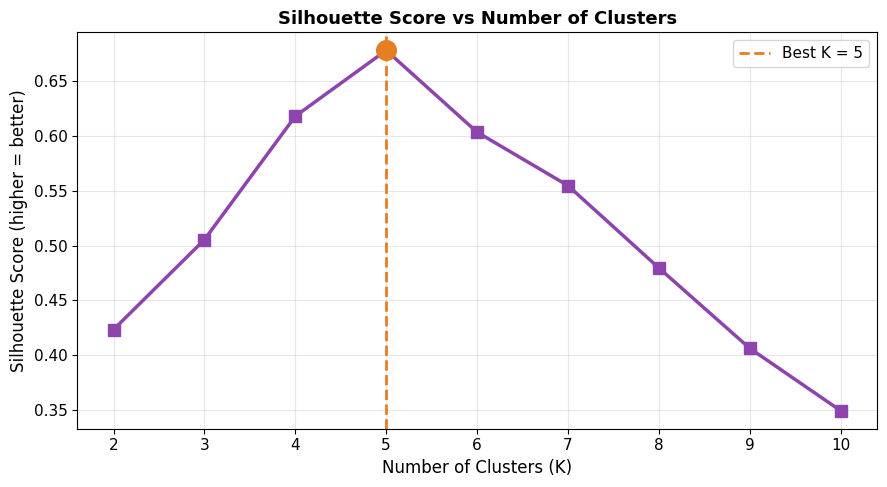

✅ Both Elbow Method and Silhouette Score agree: K = 5 is the best choice!


In [25]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='#8e44ad', linewidth=2.5, markersize=8)
plt.axvline(x=best_k, color='#e67e22', linestyle='--', linewidth=2,
            label=f'Best K = {best_k}')
plt.scatter([best_k], [sil_scores[best_k - 2]], color='#e67e22', s=200, zorder=5)
plt.title('Silhouette Score vs Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score (higher = better)', fontsize=12)
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ Both Elbow Method and Silhouette Score agree: K = {best_k} is the best choice!")

---
## 🎯 Step 7: Train K-Means with K=5

In [26]:
# Train the final model
K_BEST = 5
kmeans = KMeans(
    n_clusters=K_BEST,
    init='k-means++',    # Smart centroid initialization (better than random)
    n_init=10,           # Run 10 times, pick the best result
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means trained with K = {K_BEST}")
print()
print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index().to_string())
print()
print(f"Final WCSS (Inertia): {kmeans.inertia_:.2f}")

✅ K-Means trained with K = 5

Customers per cluster:
Cluster
0    40
1    40
2    40
3    40
4    40

Final WCSS (Inertia): 26.21


---
## 🎨 Step 8: Visualize the Clusters

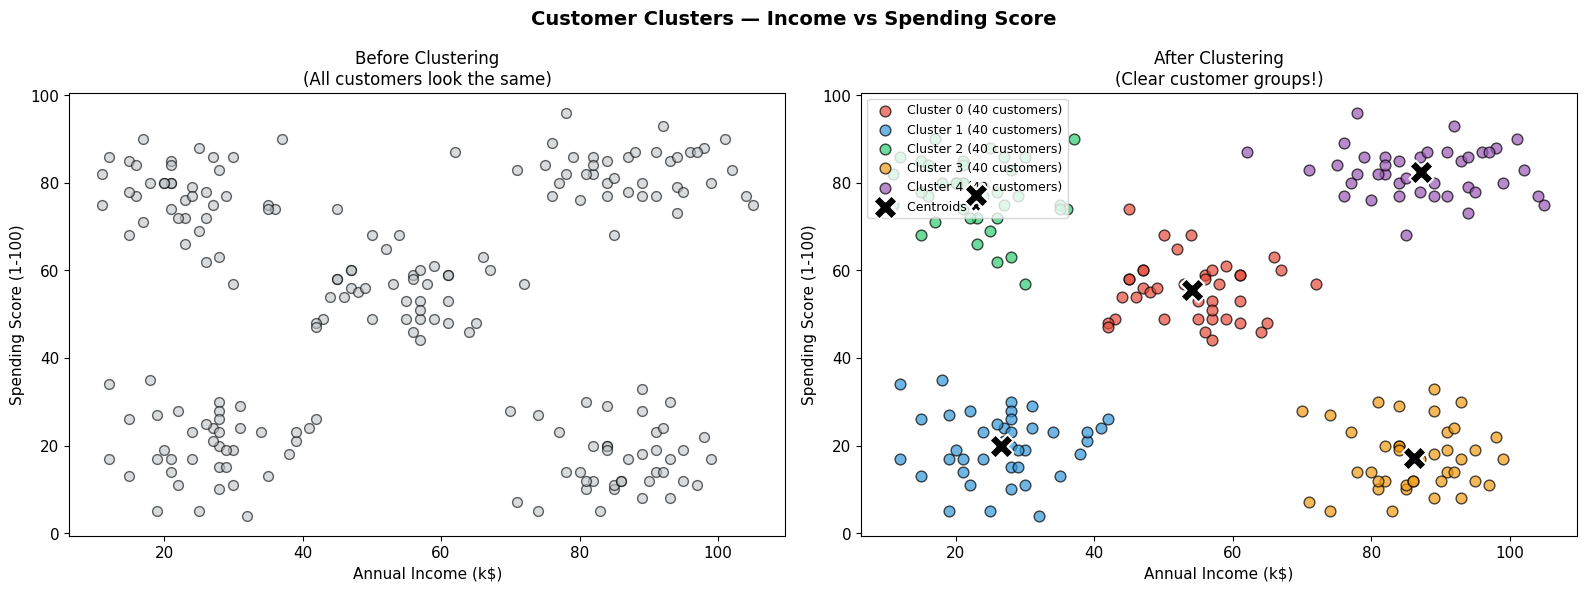

In [27]:
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
CLUSTER_LABELS = [
    'Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Clusters — Income vs Spending Score', fontsize=14, fontweight='bold')

# Plot 1: Raw data (before clustering)
axes[0].scatter(df['Annual_Income_k'], df['Spending_Score'],
                color='#bdc3c7', edgecolor='black', alpha=0.6, s=50)
axes[0].set_title('Before Clustering\n(All customers look the same)', fontsize=12)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

# Plot 2: After clustering
for c in range(K_BEST):
    mask = df['Cluster'] == c
    axes[1].scatter(
        df[mask]['Annual_Income_k'],
        df[mask]['Spending_Score'],
        color=CLUSTER_COLORS[c],
        label=f'Cluster {c} ({mask.sum()} customers)',
        edgecolor='black', alpha=0.7, s=60
    )

# Plot centroids (in original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    color='black', marker='X', s=300, zorder=10,
    label='Centroids ✖', edgecolors='white', linewidths=1.5
)

axes[1].set_title('After Clustering\n(Clear customer groups!)', fontsize=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 📊 Step 9: Understand Each Cluster — Business Insights

In [28]:
# Calculate mean of each feature per cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income_k', 'Spending_Score']].mean().round(1)
cluster_summary['Count'] = df.groupby('Cluster')['CustomerID'].count()

print("📋 Cluster Summary (Mean Values)")
print("=" * 55)
print(cluster_summary.to_string())
print()

# Auto-label clusters based on income & spending
def label_cluster(row):
    inc = row['Annual_Income_k']
    sp  = row['Spending_Score']
    if inc >= 60 and sp >= 60:
        return '💎 High Income, High Spender (VIP)'
    elif inc >= 60 and sp < 40:
        return '🤔 High Income, Low Spender (Careful Rich)'
    elif inc < 40 and sp >= 60:
        return '🛍️ Low Income, High Spender (Impulsive Buyer)'
    elif inc < 40 and sp < 40:
        return '💵 Low Income, Low Spender (Budget Shopper)'
    else:
        return '👥 Mid Income, Mid Spender (Average Customer)'

cluster_summary['Segment'] = cluster_summary.apply(label_cluster, axis=1)
print("\n🏷️  Cluster Business Labels:")
print("=" * 55)
for idx, row in cluster_summary.iterrows():
    print(f"  Cluster {idx}: {row['Segment']}")

📋 Cluster Summary (Mean Values)
          Age  Annual_Income_k  Spending_Score  Count
Cluster                                              
0        44.4             54.2            55.4     40
1        40.0             26.6            20.0     40
2        46.6             22.9            77.2     40
3        42.7             86.1            17.2     40
4        43.4             87.2            82.4     40


🏷️  Cluster Business Labels:
  Cluster 0: 👥 Mid Income, Mid Spender (Average Customer)
  Cluster 1: 💵 Low Income, Low Spender (Budget Shopper)
  Cluster 2: 🛍️ Low Income, High Spender (Impulsive Buyer)
  Cluster 3: 🤔 High Income, Low Spender (Careful Rich)
  Cluster 4: 💎 High Income, High Spender (VIP)


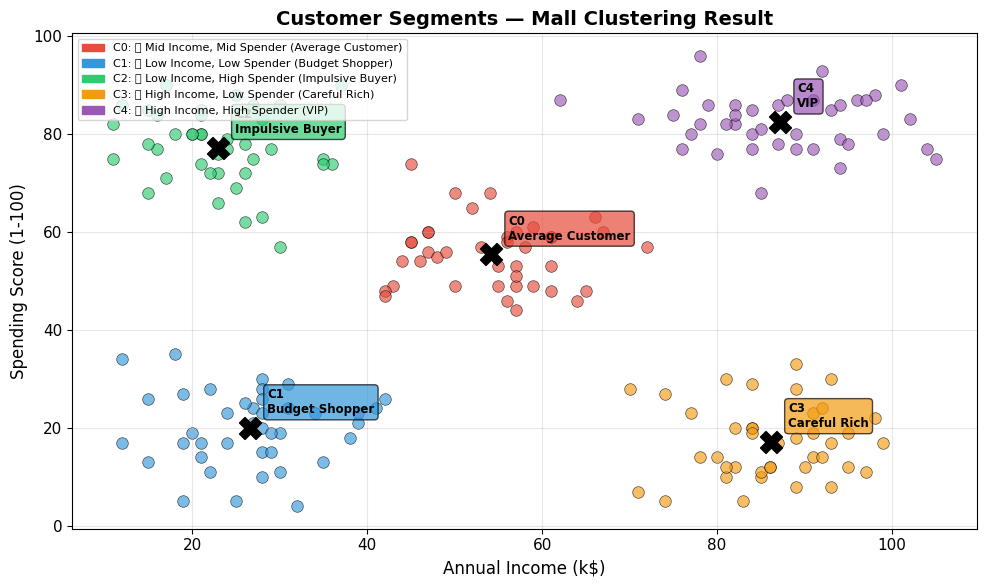

In [29]:
# Visual: Income vs Spending per cluster (bubble chart)
fig, ax = plt.subplots(figsize=(10, 6))

for c in range(K_BEST):
    mask = df['Cluster'] == c
    subset = df[mask]
    ax.scatter(
        subset['Annual_Income_k'],
        subset['Spending_Score'],
        color=CLUSTER_COLORS[c],
        alpha=0.65, s=70, edgecolor='black', linewidths=0.5
    )

# Annotate centroids with segment names
segment_names = [
    cluster_summary.loc[c, 'Segment'] for c in range(K_BEST)
]

for i, (cx, cy) in enumerate(centroids_orig):
    ax.scatter(cx, cy, color='black', marker='X', s=250, zorder=10)
    ax.annotate(
        f'C{i}\n{segment_names[i].split("(")[1].replace(")", "") if "(" in segment_names[i] else ""}',
        xy=(cx, cy), xytext=(cx + 2, cy + 3),
        fontsize=8.5, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=CLUSTER_COLORS[i], alpha=0.7)
    )

ax.set_title('Customer Segments — Mall Clustering Result', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.grid(True, alpha=0.3)

legend_handles = [mpatches.Patch(color=CLUSTER_COLORS[c],
                                  label=f'C{c}: {segment_names[c]}')
                  for c in range(K_BEST)]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 💡 Step 10: Predict the Cluster for a New Customer

In [30]:
# New customer walks in — which cluster do they belong to?
new_customers = pd.DataFrame({
    'Annual_Income_k': [90, 30, 55],
    'Spending_Score':  [85, 75, 50]
})

print("New Customers:")
print(new_customers.to_string(index=False))

# Scale using the SAME scaler as training!
new_scaled = scaler.transform(new_customers)
predicted_clusters = kmeans.predict(new_scaled)

print("\n🔮 Predictions:")
print("=" * 55)
for i, (_, row) in enumerate(new_customers.iterrows()):
    c = predicted_clusters[i]
    seg = cluster_summary.loc[c, 'Segment']
    print(f"  Customer {i+1}: Income={row['Annual_Income_k']}k, Spending={row['Spending_Score']}")
    print(f"  → Cluster {c}: {seg}")
    print()

New Customers:
 Annual_Income_k  Spending_Score
              90              85
              30              75
              55              50

🔮 Predictions:
  Customer 1: Income=90k, Spending=85
  → Cluster 4: 💎 High Income, High Spender (VIP)

  Customer 2: Income=30k, Spending=75
  → Cluster 2: 🛍️ Low Income, High Spender (Impulsive Buyer)

  Customer 3: Income=55k, Spending=50
  → Cluster 0: 👥 Mid Income, Mid Spender (Average Customer)



---
## ⚠️ Step 11: Limitations of K-Means

K-Means is powerful but not perfect. Know when NOT to use it:

| Problem | Explanation |
|---|---|
| **You must choose K** | No automatic K selection |
| **Sensitive to outliers** | One extreme point can pull the centroid |
| **Assumes spherical clusters** | Won't work well for ring/crescent shaped groups |
| **Feature scale matters** | Always scale features before clustering! |
| **Random initialization** | Different runs may give different results (use `n_init=10`) |

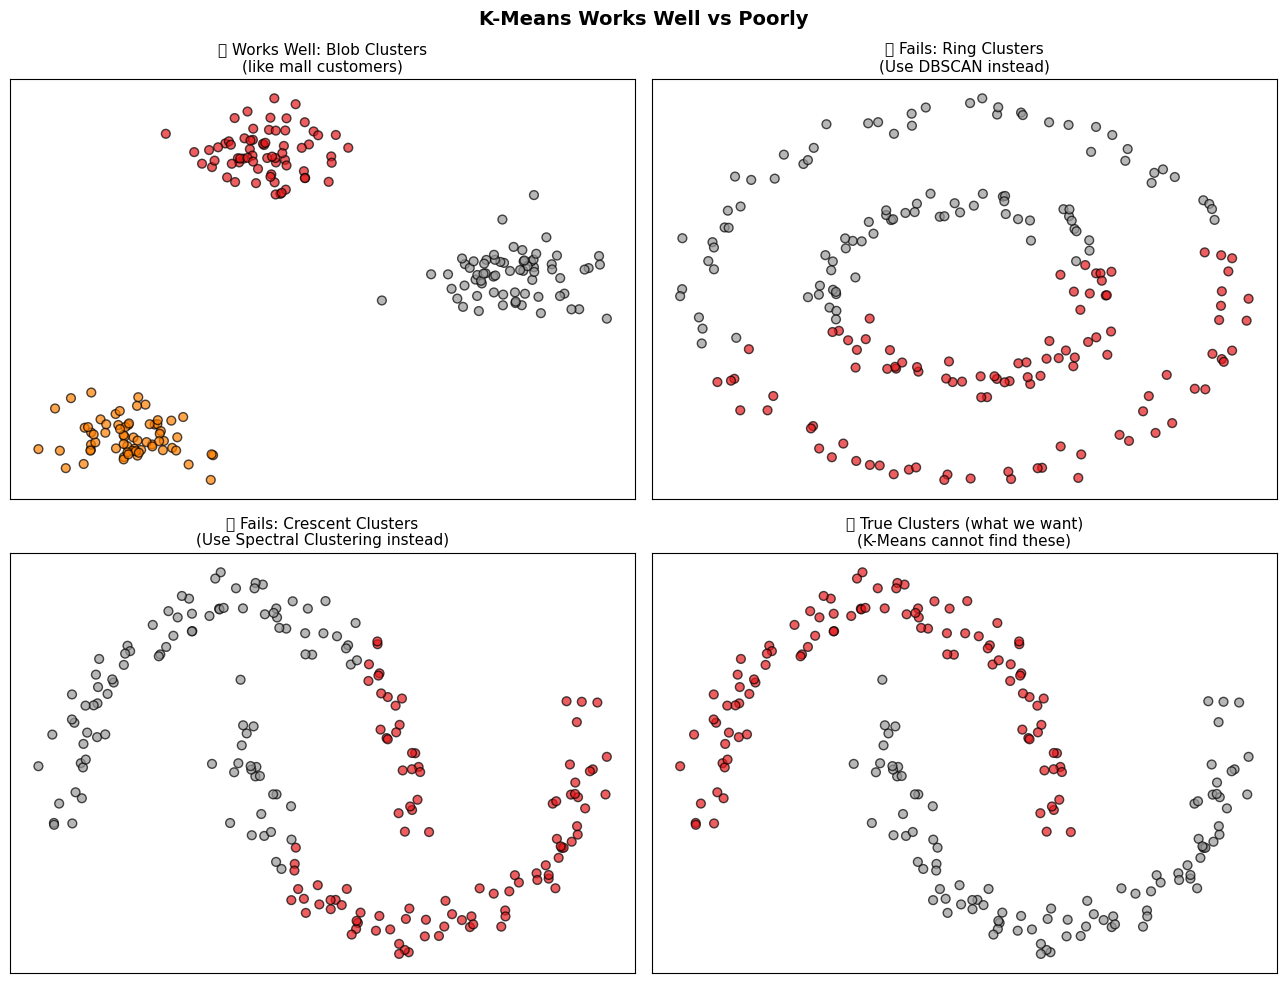

💡 K-Means works best when clusters are roughly circular (blob-shaped).
   For complex shapes → DBSCAN or Spectral Clustering are better options.


In [31]:
# Demo: K-Means struggles with non-spherical (ring) shapes
from sklearn.datasets import make_circles, make_moons

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('K-Means Works Well vs Poorly', fontsize=14, fontweight='bold')

# Good case: Blob clusters (like our mall data)
from sklearn.datasets import make_blobs
X_blobs, _ = make_blobs(n_samples=200, centers=3, random_state=42, cluster_std=1.2)
km_blobs = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_blobs)

axes[0, 0].scatter(X_blobs[:, 0], X_blobs[:, 1],
                   c=km_blobs.labels_, cmap='Set1', edgecolor='k', alpha=0.7, s=40)
axes[0, 0].set_title('✅ Works Well: Blob Clusters\n(like mall customers)', fontsize=11)

# Bad case 1: Ring (concentric circles)
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
km_circles = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_circles)

axes[0, 1].scatter(X_circles[:, 0], X_circles[:, 1],
                   c=km_circles.labels_, cmap='Set1', edgecolor='k', alpha=0.7, s=40)
axes[0, 1].set_title('❌ Fails: Ring Clusters\n(Use DBSCAN instead)', fontsize=11)

# Bad case 2: Moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.07, random_state=42)
km_moons = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_moons)

axes[1, 0].scatter(X_moons[:, 0], X_moons[:, 1],
                   c=km_moons.labels_, cmap='Set1', edgecolor='k', alpha=0.7, s=40)
axes[1, 0].set_title('❌ Fails: Crescent Clusters\n(Use Spectral Clustering instead)', fontsize=11)

# With true labels (what it should look like)
axes[1, 1].scatter(X_moons[:, 0], X_moons[:, 1],
                   c=y_moons, cmap='Set1', edgecolor='k', alpha=0.7, s=40)
axes[1, 1].set_title('✅ True Clusters (what we want)\n(K-Means cannot find these)', fontsize=11)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("💡 K-Means works best when clusters are roughly circular (blob-shaped).")
print("   For complex shapes → DBSCAN or Spectral Clustering are better options.")

---
# 🧠 Full Summary

## What We Covered Today

| Concept | Key Point |
|---|---|
| **Clustering** | Group similar data points together (unsupervised) |
| **K-Means** | Iteratively move centroids until clusters stabilize |
| **Elbow Method** | Plot WCSS vs K — pick where the bend is |
| **Silhouette Score** | Validates cluster quality (higher = better) |
| **k-means++** | Smart initialization for better results |
| **Feature Scaling** | Always scale before K-Means! |
| **Limitations** | Fails on ring/crescent shapes, needs K upfront |

## Real-World Applications

- 🛒 **Retail** — Customer segmentation (like we did today!)
- 📧 **Email** — Group similar emails (spam detection)
- 🏥 **Healthcare** — Group patients by symptoms
- 🎵 **Music** — Group songs by audio features (Spotify)
- 🗺️ **Maps** — Group nearby locations (Google Maps)

---

## 🏋️ Try It Yourself!

1. Change `K_BEST = 3` and re-run — how do the clusters change?
2. Add `Age` as a 3rd feature for clustering — does it improve results?
3. Try removing `StandardScaler` — see how badly the clusters break!
4. Cluster male and female customers separately — any difference?